In [2]:
import sys
import os
import json
import numpy as np
sys.path.append("../")
import utils.kitti_loader as kitti_loader
import matplotlib.pyplot as plt

In [3]:
lidar = kitti_loader.get_LiDAR(count=10)
images = kitti_loader.get_images(count=10)

In [4]:
for i in images:
    print(i.shape)

(375, 1200, 3)
(375, 1200, 3)
(375, 1200, 3)
(375, 1200, 3)
(375, 1200, 3)
(375, 1200, 3)
(375, 1200, 3)
(375, 1200, 3)
(375, 1200, 3)
(375, 1200, 3)


In [3]:
fps_lidar = [kitti_loader.lidar_fps(l) for l in lidar]


In [4]:
import utils.kitti_loader as kitti_loader
kitti_loader??

Type:        module
String form: <module 'utils.kitti_loader' from 'f:\\Work\\DeepLearning\\Research\\fusion\\..\\utils\\kitti_loader.py'>
File:        f:\work\deeplearning\research\utils\kitti_loader.py
Source:     
import os
import numpy as np
import matplotlib.pyplot as plt
ROOTDIR = r'F:\Work\DeepLearning\Research\dataset'

def find_kitti_files(root_dir=ROOTDIR, split="train"):
    """
    Find all KITTI LiDAR .bin files (train/test) from your folder structure.
    
    Args:
        root_dir (str): Base dataset folder (e.g., F:\\Work\\DeepLearning\\Research\\dataset)
        split (str): 'train' or 'test'
    
    Returns:
        list: Sorted list of full file paths to .bin files
    """
    if split == 'train':
        lidar_dir = os.path.join(ROOTDIR, 'data_object_velodyne', 'training', 'velodyne')
    else:
        lidar_dir = os.path.join(ROOTDIR, 'data_object_velodyne', 'testing', 'velodyne')
    
    if not os.path.exists(lidar_dir):
        raise FileNotFoundError(f"Path n

In [5]:
calib = kitti_loader.get_calib(10)

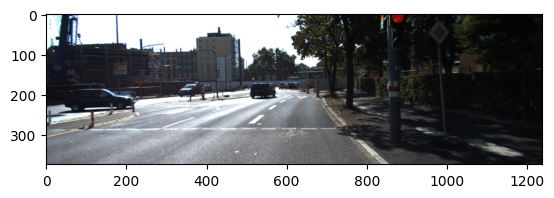

In [8]:
calib_0 = calib[6]
lidar_0 = lidar[6]
image_0 = images[6]
plt.imshow(image_0)

In [9]:
calib_0

{'P0': array([718.3351,   0.    , 600.3891,   0.    ,   0.    , 718.3351,
        181.5122,   0.    ,   0.    ,   0.    ,   1.    ,   0.    ]),
 'P1': array([ 718.3351,    0.    ,  600.3891, -385.8846,    0.    ,  718.3351,
         181.5122,    0.    ,    0.    ,    0.    ,    1.    ,    0.    ]),
 'P2': array([ 7.183351e+02,  0.000000e+00,  6.003891e+02,  4.450382e+01,
         0.000000e+00,  7.183351e+02,  1.815122e+02, -5.951107e-01,
         0.000000e+00,  0.000000e+00,  1.000000e+00,  2.616315e-03]),
 'P3': array([ 7.183351e+02,  0.000000e+00,  6.003891e+02, -3.363147e+02,
         0.000000e+00,  7.183351e+02,  1.815122e+02,  3.159867e+00,
         0.000000e+00,  0.000000e+00,  1.000000e+00,  5.323834e-03]),
 'R0_rect': array([ 0.9999478 ,  0.00979171, -0.00292531, -0.00980694,  0.9999382 ,
        -0.00523872,  0.00287383,  0.00526713,  0.999982  ]),
 'Tr_velo_to_cam': array([ 0.00775545, -0.9999694 , -0.0010143 , -0.00727554,  0.00229406,
         0.00103212, -0.9999968 , -0.06

In [10]:
calib_0["P2"].reshape(3,4)

array([[ 7.183351e+02,  0.000000e+00,  6.003891e+02,  4.450382e+01],
       [ 0.000000e+00,  7.183351e+02,  1.815122e+02, -5.951107e-01],
       [ 0.000000e+00,  0.000000e+00,  1.000000e+00,  2.616315e-03]])

In [11]:
lidar_0.shape

(110089, 4)

In [12]:
p_velo = np.hstack([lidar_0[:, :3], np.ones((lidar_0.shape[0], 1))]).T

In [13]:
x_cam = calib_0["Tr_velo_to_cam"].reshape(3, 4) @ p_velo

In [14]:
x_rect = (calib_0["R0_rect"].reshape(3, 3) @ x_cam)

In [15]:
X_rect = np.vstack([x_rect, np.ones((1, x_rect.shape[1]))])
x_img = calib_0["P2"].reshape(3, 4) @ X_rect
x_img /= x_img[2, :]
x_img = x_img[:2, :].T

In [16]:
image_0.shape

(374, 1238, 3)

In [26]:
x_img.shape

(110089, 2)

In [17]:
H, W, _ = image_0.shape
mask = (x_img[:, 0] >= 0) & (x_img[:, 0] < W) & (x_img[:, 1] >= 0) & (x_img[:, 1] < H)

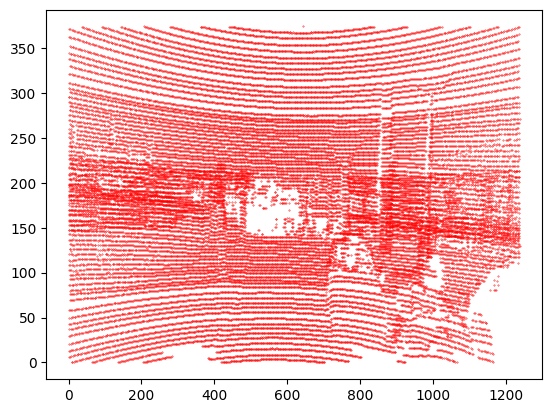

In [18]:
plt.scatter(x_img[mask, 0], x_img[mask, 1], s=0.1, c='r')

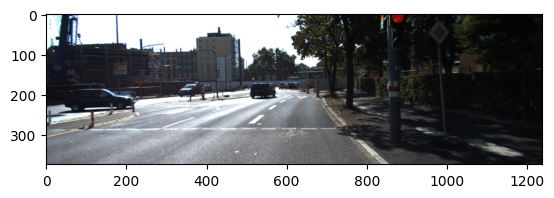

In [19]:
plt.imshow(image_0)

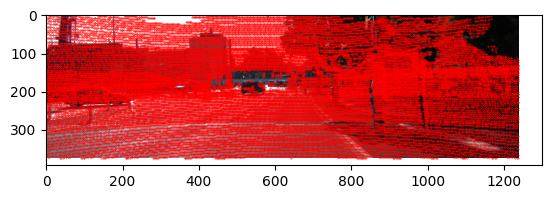

In [20]:
plt.imshow(image_0)
plt.scatter(x_img[mask, 0], x_img[mask, 1], s=0.1, c='r')
plt.show()

In [21]:
image_0.shape

(374, 1238, 3)

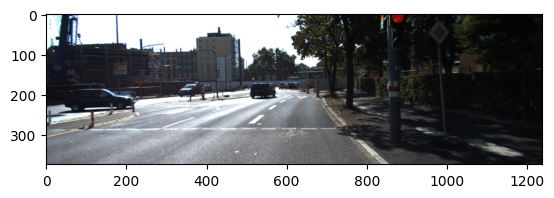

In [22]:
plt.imshow(image_0)

In [23]:
import numpy as np
import open3d as o3d

# x_rect: shape (3, N)  -> 3D rectified camera points
# X_rect you made is 4 x N (with the extra 1s row)
# So just use x_rect to plot in Open3D

# x_rect is (3, N) -> make it (N, 3)
points_3d = x_rect.T   # shape (N, 3)

# Create Open3D point cloud
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(x_rect.T)

# (Optional) give some uniform color
pcd.paint_uniform_color([1.0, 0.0, 0.0])  # red

# Visualize
o3d.visualization.draw_geometries([pcd])


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [24]:
import torch 
import torch.nn as nn
import torch.nn.functional as F


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np

# ========================================
# CONVERT NUMPY TO TORCH TENSORS
# ========================================

# 1. Convert image to tensor
# image_0 shape: (374, 1238, 3) - numpy array (H, W, C)
image_tensor = torch.from_numpy(image_0).float()  # (374, 1238, 3)

# Rearrange to PyTorch format: (C, H, W)
image_tensor = image_tensor.permute(2, 0, 1)  # (3, 374, 1238)

# Add batch dimension: (B, C, H, W)
image_tensor = image_tensor.unsqueeze(0)  # (1, 3, 374, 1238)

print(f"Image tensor shape: {image_tensor.shape}")


# 2. Convert pixel coordinates to tensor
# x_img shape: (110089, 2) - numpy array with (x, y) coordinates
x_img_tensor = torch.from_numpy(x_img).float()  # (110089, 2)

print(f"Pixel coords shape: {x_img_tensor.shape}")


# ========================================
# NORMALIZE COORDINATES TO [-1, 1]
# ========================================
B, C, H, W = image_tensor.shape  # (1, 3, 374, 1238)
N = x_img_tensor.shape[0]  # 110089 points

# grid_sample expects coordinates in [-1, 1] range
# Current: x in [0, W-1], y in [0, H-1]
# Target:  x in [-1, 1], y in [-1, 1]

normalized_coords = x_img_tensor.clone()
normalized_coords[:, 0] = 2.0 * x_img_tensor[:, 0] / (W - 1) - 1.0  # x
normalized_coords[:, 1] = 2.0 * x_img_tensor[:, 1] / (H - 1) - 1.0  # y

print(f"Normalized coords range: x=[{normalized_coords[:, 0].min():.2f}, {normalized_coords[:, 0].max():.2f}], "
      f"y=[{normalized_coords[:, 1].min():.2f}, {normalized_coords[:, 1].max():.2f}]")


# ========================================
# RESHAPE FOR GRID_SAMPLE
# ========================================
# grid_sample expects: (B, H_out, W_out, 2)
# We want: (B, N, 1, 2) where N = number of points

grid = normalized_coords.view(1, N, 1, 2)  # (1, 110089, 1, 2)

print(f"Grid shape: {grid.shape}")


# ========================================
# BILINEAR INTERPOLATION
# ========================================
Bilinear_image_lidar = F.grid_sample(
    image_tensor,   # (1, 3, 374, 1238)
    grid,           # (1, 110089, 1, 2)
    mode='bilinear',
    padding_mode='zeros',
    align_corners=True
)

print(f"Output shape: {Bilinear_image_lidar.shape}")  # (1, 3, 110089, 1)


# ========================================
# RESHAPE TO POINT-WISE FEATURES
# ========================================
# Remove extra dimensions and rearrange
# (1, 3, 110089, 1) -> (110089, 3)

point_wise_image_features = Bilinear_image_lidar.squeeze(-1).squeeze(0).T
# OR equivalently:
# point_wise_image_features = Bilinear_image_lidar.squeeze().T

print(f"Final point-wise features shape: {point_wise_image_features.shape}")   

Image tensor shape: torch.Size([1, 3, 374, 1238])
Pixel coords shape: torch.Size([110089, 2])
Normalized coords range: x=[-25138.61, 823702.69], y=[-32258.19, 160452.86]
Grid shape: torch.Size([1, 110089, 1, 2])
Output shape: torch.Size([1, 3, 110089, 1])
Final point-wise features shape: torch.Size([110089, 3])


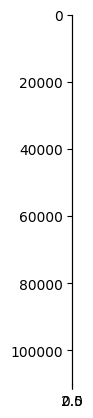

In [31]:
plt.imshow(point_wise_image_features)

In [30]:
point_wise_image_features.shape

torch.Size([110089, 3])

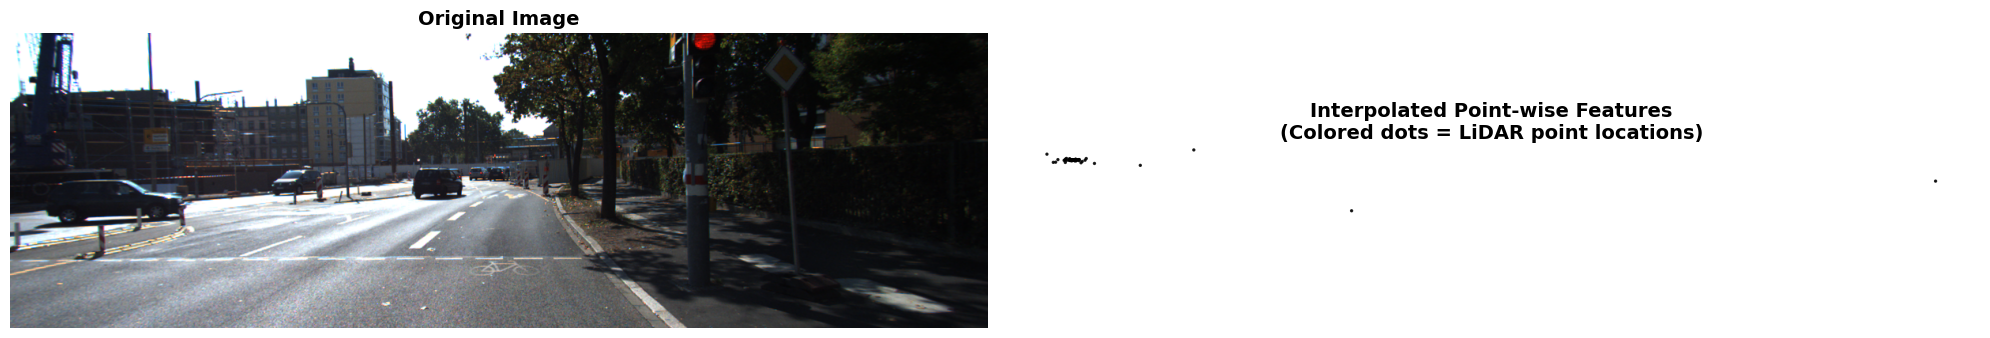

In [46]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# LEFT: Original Image
axes[0].imshow(image_0)
axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
axes[0].axis('off')

# RIGHT: Interpolated Features Overlaid
axes[1].imshow(image_0)
axes[1].scatter(x_img[:, 0], x_img[:, 1], 
                c=point_wise_image_features.numpy()/255.0, 
                s=2, alpha=0.8)
axes[1].set_title('Interpolated Point-wise Features\n(Colored dots = LiDAR point locations)', 
                  fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

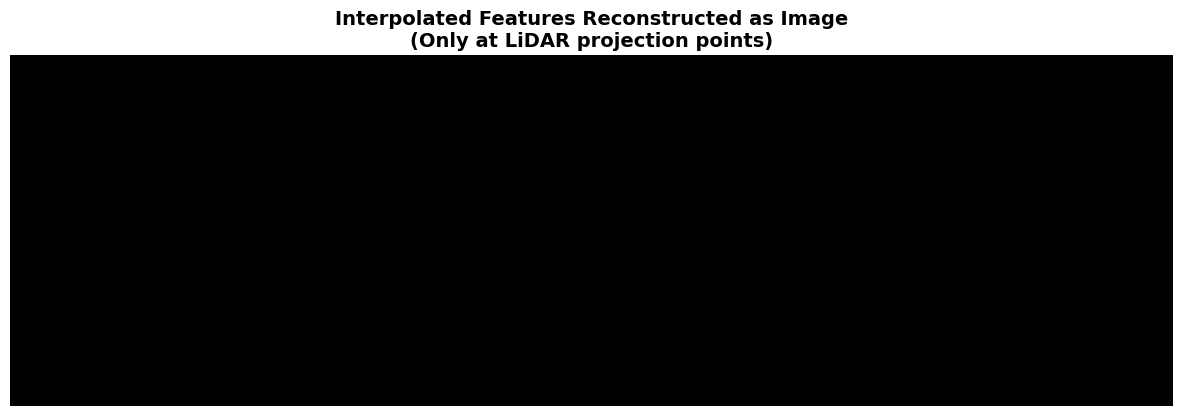

In [47]:
plt.figure(figsize=(15, 6))

# Create black background
background = np.zeros_like(image_0)

# Place interpolated colors at pixel locations
for i in range(len(x_img)):
    x, y = int(x_img[i, 0]), int(x_img[i, 1])
    if 0 <= x < image_0.shape[1] and 0 <= y < image_0.shape[0]:
        background[y, x] = point_wise_image_features[i].numpy()

plt.imshow(background.astype(np.uint8))
plt.title('Interpolated Features Reconstructed as Image\n(Only at LiDAR projection points)', 
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

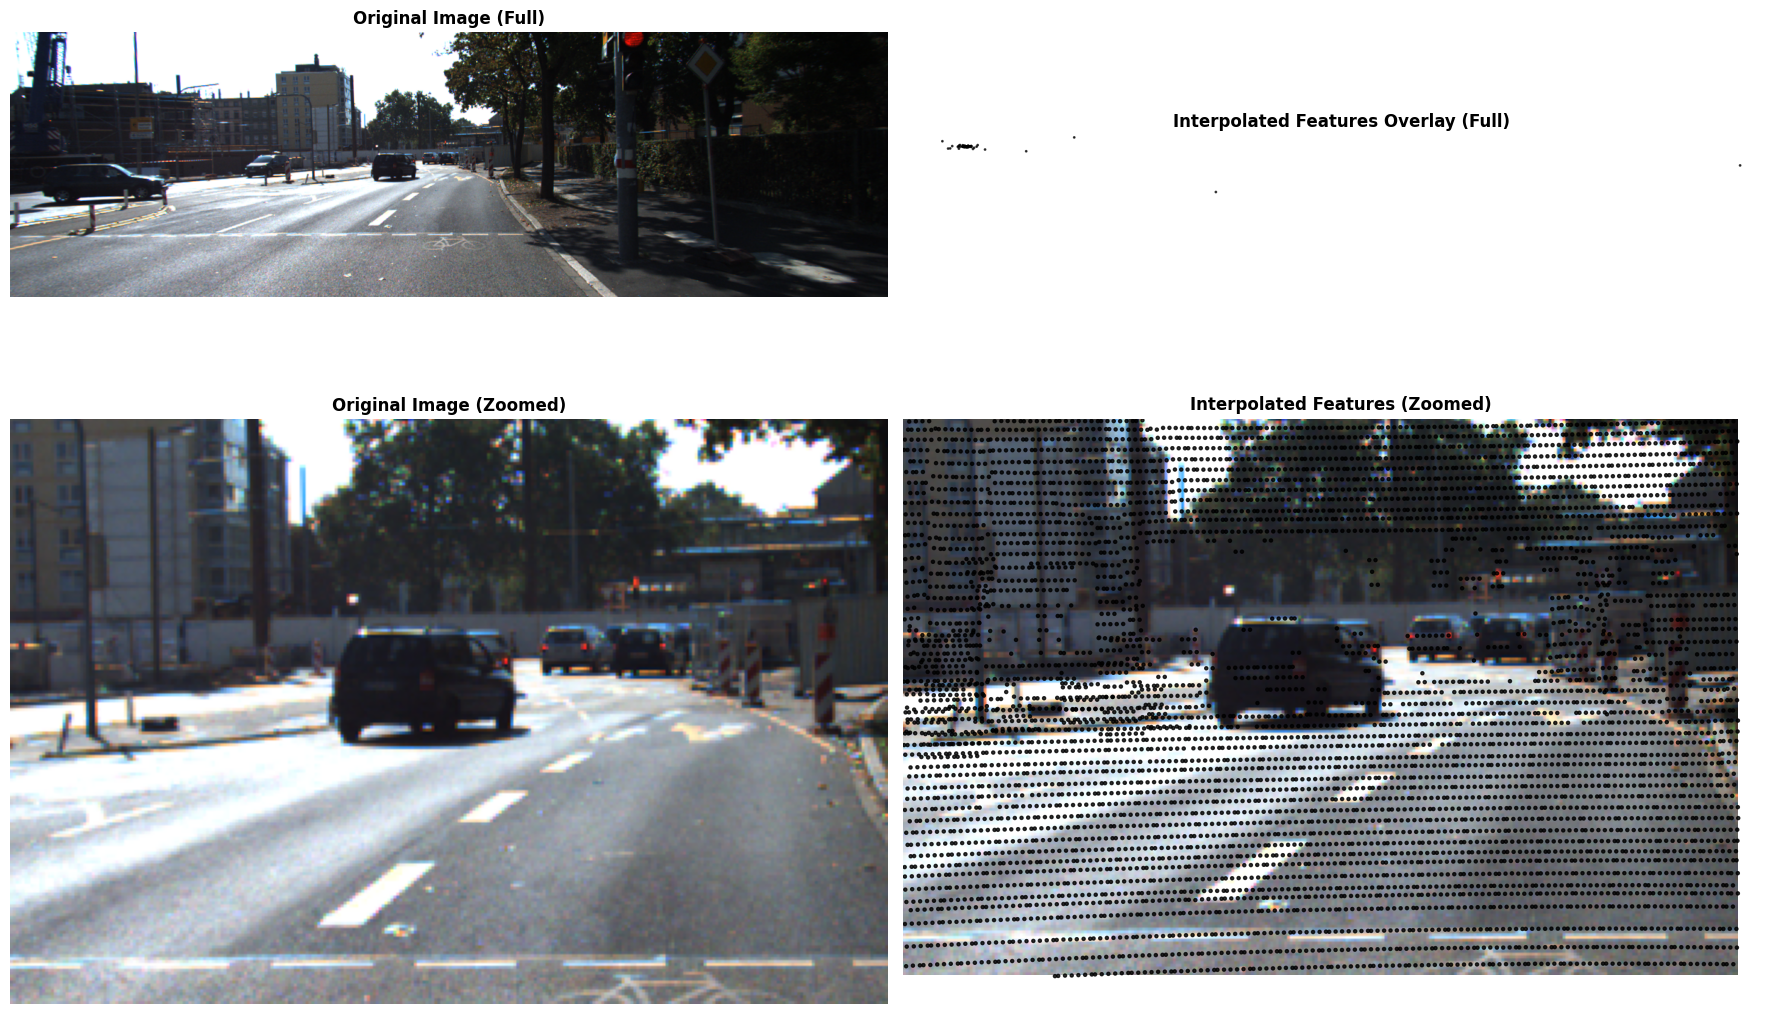

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Top Left: Full original image
axes[0, 0].imshow(image_0)
axes[0, 0].set_title('Original Image (Full)', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# Top Right: Full interpolated overlay
axes[0, 1].imshow(image_0)
axes[0, 1].scatter(x_img[:, 0], x_img[:, 1], 
                   c=point_wise_image_features.numpy()/255.0, 
                   s=1, alpha=0.7)
axes[0, 1].set_title('Interpolated Features Overlay (Full)', fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

# Define zoom region (center area)
zoom_x, zoom_y, zoom_w, zoom_h = 400, 100, 300, 200

# Bottom Left: Zoomed original
axes[1, 0].imshow(image_0[zoom_y:zoom_y+zoom_h, zoom_x:zoom_x+zoom_w])
axes[1, 0].set_title('Original Image (Zoomed)', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

# Bottom Right: Zoomed interpolated
axes[1, 1].imshow(image_0[zoom_y:zoom_y+zoom_h, zoom_x:zoom_x+zoom_w])
# Filter points in zoom region
mask = (x_img[:, 0] >= zoom_x) & (x_img[:, 0] < zoom_x+zoom_w) & \
       (x_img[:, 1] >= zoom_y) & (x_img[:, 1] < zoom_y+zoom_h)
axes[1, 1].scatter(x_img[mask, 0] - zoom_x, 
                   x_img[mask, 1] - zoom_y,
                   c=point_wise_image_features[mask].numpy()/255.0,
                   s=5, alpha=0.8)
axes[1, 1].set_title('Interpolated Features (Zoomed)', fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

In [1]:
"""
Complete Training Pipeline for Point-GNN on V2X-Radar-V Dataset
Run this file to train the Point-GNN model for 3D object detection
"""

import os
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from tqdm import tqdm
import json
from datetime import datetime
import time

sys.path.append(os.path.join(os.path.dirname(__file__), '..'))
from GNN import PointGNN, intializer
from utils import data_loader as kitti_loader


# ========================== Configuration ==========================

class Config:
    """Training configuration"""
    # Dataset
    DATASET_ROOT = r'F:\Work\DeepLearning\Research\V2X-Radar-V'
    
    # Model
    NUM_ITERATIONS = 3
    STATE_DIM = 128
    GRAPH_RADIUS = 4.0
    
    # Training
    NUM_EPOCHS = 50
    LEARNING_RATE = 0.125
    LR_DECAY_RATE = 0.1
    LR_DECAY_STEPS = [20, 35]  # Decay at these epochs
    BATCH_SIZE = 1  # Due to variable graph sizes
    NUM_WORKERS = 0
    
    # Loss weights (from paper: α=0.1, β=10, γ=5e-7)
    ALPHA = 0.1  # Classification loss weight
    BETA = 10.0  # Localization loss weight
    GAMMA = 5e-7  # Regularization weight
    
    # Classes: 0=Background, 1=Car, 2=Pedestrian, 3=Cyclist
    CLASS_NAMES = ['Background', 'Car', 'Pedestrian', 'Cyclist']
    NUM_CLASSES = 4
    
    # Scale factors for bbox encoding (from paper for Car)
    SCALE_FACTORS = {
        'l_m': 3.88,   # median length
        'h_m': 1.5,    # median height
        'w_m': 1.63,   # median width
        'theta_0': 0.0,
        'theta_m': 1.57
    }
    
    # Output
    CHECKPOINT_DIR = './checkpoints'
    LOG_DIR = './logs'
    SAVE_FREQ = 5  # Save every N epochs


# ========================== Label Parser ==========================

def parse_kitti_label(label_lines):
    """
    Parse KITTI format label file.
    
    Label format per line:
    type truncated occluded alpha bbox_2d(4) dimensions(3) location(3) rotation_y [score]
    
    Returns:
        list of dicts with keys: type, bbox_3d(x,y,z,l,h,w,theta)
    """
    objects = []
    for line in label_lines:
        parts = line.strip().split()
        if len(parts) < 15:
            continue
        
        obj_type = parts[0]  # Car, Pedestrian, Cyclist, etc.
        
        # Skip DontCare objects
        if obj_type == 'DontCare':
            continue
        
        # 3D bounding box: h, w, l at indices 8,9,10
        h, w, l = float(parts[8]), float(parts[9]), float(parts[10])
        # Location: x, y, z at indices 11,12,13
        x, y, z = float(parts[11]), float(parts[12]), float(parts[13])
        # Rotation: rotation_y at index 14
        rotation_y = float(parts[14])
        
        objects.append({
            'type': obj_type,
            'bbox_3d': np.array([x, y, z, l, h, w, rotation_y], dtype=np.float32)
        })
    
    return objects


# ========================== Dataset ==========================

class PointGNNDataset(Dataset):
    """Dataset for Point-GNN training on KITTI/V2X-Radar-V format"""
    
    def __init__(self, config, split='train', max_samples=None):
        """
        Args:
            config: Configuration object
            split: 'train' or 'test'
            max_samples: Limit dataset size for debugging
        """
        self.config = config
        self.split = split
        self.class_mapping = {'Car': 1, 'Pedestrian': 2, 'Cyclist': 3}
        
        print(f"\n{'='*60}")
        print(f"Loading {split} dataset from {config.DATASET_ROOT}")
        print(f"{'='*60}")
        
        # Load data
        try:
            self.lidar_data = kitti_loader.get_LiDAR(
                config.DATASET_ROOT, split, count=max_samples
            )
            self.labels = kitti_loader.get_labels(
                config.DATASET_ROOT, split, count=max_samples
            )
        except Exception as e:
            print(f"Error loading data: {e}")
            raise
        
        # Filter samples without objects (for training)
        if split == 'train':
            valid_indices = []
            for idx in range(len(self.labels)):
                objects = parse_kitti_label(self.labels[idx])
                # Only keep samples with at least one relevant object
                if any(obj['type'] in self.class_mapping for obj in objects):
                    valid_indices.append(idx)
            
            print(f"Filtered {len(valid_indices)}/{len(self.lidar_data)} samples with objects")
            self.lidar_data = [self.lidar_data[i] for i in valid_indices]
            self.labels = [self.labels[i] for i in valid_indices]
        
        print(f"Dataset size: {len(self.lidar_data)} samples")
        print(f"{'='*60}\n")
    
    def __len__(self):
        return len(self.lidar_data)
    
    def __getitem__(self, idx):
        """
        Returns:
            dict with keys:
                - graph_data: constructed graph
                - gt_labels: (N,) vertex class labels
                - gt_bboxes: (N, 7) ground truth bboxes
                - is_object_mask: (N,) boolean mask
        """
        # Load point cloud
        points = self.lidar_data[idx].copy()
        
        # Downsample for efficiency (like in paper)
        if len(points) > 16384:
            points = kitti_loader.lidar_fps(points, N=16384)
        
        # Construct graph
        graph_data = intializer.construct_graph(points, radius=self.config.GRAPH_RADIUS)
        vertex_coords = graph_data['vertex_coords'].numpy()
        N = len(vertex_coords)
        
        # Parse labels
        label_lines = self.labels[idx]
        objects = parse_kitti_label(label_lines)
        
        # Initialize ground truth arrays
        gt_labels = np.zeros(N, dtype=np.int64)  # 0 = background
        gt_bboxes = np.zeros((N, 7), dtype=np.float32)
        is_object_mask = np.zeros(N, dtype=np.float32)
        
        # Assign labels to vertices (vertices inside bbox get object label)
        for obj in objects:
            if obj['type'] not in self.class_mapping:
                continue
            
            class_id = self.class_mapping[obj['type']]
            bbox = obj['bbox_3d']
            x, y, z, l, h, w, theta = bbox
            
            # Find vertices inside this bounding box (simple AABB check)
            dx = np.abs(vertex_coords[:, 0] - x)
            dy = np.abs(vertex_coords[:, 1] - y)
            dz = np.abs(vertex_coords[:, 2] - z)
            
            inside_mask = (dx < l/2) & (dy < w/2) & (dz < h/2)
            
            # Assign labels to vertices inside this box
            gt_labels[inside_mask] = class_id
            gt_bboxes[inside_mask] = bbox
            is_object_mask[inside_mask] = 1.0
        
        return {
            'graph_data': graph_data,
            'gt_labels': torch.tensor(gt_labels, dtype=torch.long),
            'gt_bboxes': torch.tensor(gt_bboxes, dtype=torch.float32),
            'is_object_mask': torch.tensor(is_object_mask, dtype=torch.float32),
            'idx': idx
        }


# ========================== Loss Function ==========================

class PointGNNLoss(nn.Module):
    """
    Multi-task loss from Point-GNN paper:
    L_total = α*L_cls + β*L_loc + γ*L_reg
    """
    
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.alpha = config.ALPHA
        self.beta = config.BETA
        self.gamma = config.GAMMA
    
    def encode_bbox(self, bbox, vertex_coords):
        """
        Encode bbox relative to vertex coordinates (Equation 7 from paper)
        
        Args:
            bbox: (N, 7) - (x, y, z, l, h, w, θ)
            vertex_coords: (N, 3) - (x_v, y_v, z_v)
        Returns:
            encoded_bbox: (N, 7) - (δx, δy, δz, δl, δh, δw, δθ)
        """
        sf = self.config.SCALE_FACTORS
        
        # Unpack bbox
        x = bbox[:, 0]
        y = bbox[:, 1]
        z = bbox[:, 2]
        l = bbox[:, 3]
        h = bbox[:, 4]
        w = bbox[:, 5]
        theta = bbox[:, 6]
        
        # Unpack vertex coords
        x_v = vertex_coords[:, 0]
        y_v = vertex_coords[:, 1]
        z_v = vertex_coords[:, 2]
        
        # Encode (Equation 7)
        delta_x = (x - x_v) / sf['l_m']
        delta_y = (y - y_v) / sf['h_m']
        delta_z = (z - z_v) / sf['w_m']
        delta_l = torch.log(l / sf['l_m'] + 1e-6)
        delta_h = torch.log(h / sf['h_m'] + 1e-6)
        delta_w = torch.log(w / sf['w_m'] + 1e-6)
        delta_theta = (theta - sf['theta_0']) / sf['theta_m']
        
        encoded = torch.stack([
            delta_x, delta_y, delta_z, 
            delta_l, delta_h, delta_w, 
            delta_theta
        ], dim=1)
        
        return encoded
    
    def forward(self, cls_logits, bbox_pred, gt_labels, gt_bboxes, 
                vertex_coords, is_object_mask, model):
        """
        Compute total loss
        
        Args:
            cls_logits: (N, num_classes) - predicted class logits
            bbox_pred: (N, 7) - predicted bboxes
            gt_labels: (N,) - ground truth class indices
            gt_bboxes: (N, 7) - ground truth bboxes
            vertex_coords: (N, 3) - vertex coordinates
            is_object_mask: (N,) - mask for vertices in objects
            model: model for L1 regularization
        
        Returns:
            total_loss, loss_dict
        """
        device = cls_logits.device
        N = cls_logits.shape[0]
        
        # ===== Classification Loss (Equation 6) =====
        # Cross-entropy loss
        loss_cls = F.cross_entropy(cls_logits, gt_labels, reduction='mean')
        
        # ===== Localization Loss (Equation 8) =====
        # Only compute for vertices inside objects
        if is_object_mask.sum() > 0:
            # Get object vertices
            obj_mask = is_object_mask > 0
            
            # Encode ground truth bboxes
            gt_encoded = self.encode_bbox(gt_bboxes[obj_mask], vertex_coords[obj_mask])
            pred_encoded = bbox_pred[obj_mask]
            
            # Huber loss (smooth L1)
            loss_loc = F.smooth_l1_loss(pred_encoded, gt_encoded, reduction='mean')
        else:
            loss_loc = torch.tensor(0.0, device=device)
        
        # ===== L1 Regularization =====
        loss_reg = 0.0
        for param in model.parameters():
            loss_reg += torch.abs(param).sum()
        
        # ===== Total Loss (Equation 9) =====
        loss_total = (self.alpha * loss_cls + 
                     self.beta * loss_loc + 
                     self.gamma * loss_reg)
        
        loss_dict = {
            'total': loss_total.item(),
            'cls': loss_cls.item(),
            'loc': loss_loc.item() if torch.is_tensor(loss_loc) else 0.0,
            'reg': loss_reg.item() if torch.is_tensor(loss_reg) else loss_reg
        }
        
        return loss_total, loss_dict


# ========================== Training ==========================

def train_epoch(model, dataloader, criterion, optimizer, device, epoch):
    """Train for one epoch"""
    model.train()
    
    running_loss = {
        'total': 0.0,
        'cls': 0.0,
        'loc': 0.0,
        'reg': 0.0
    }
    
    pbar = tqdm(dataloader, desc=f'Epoch {epoch}')
    
    for batch_idx, batch in enumerate(pbar):
        # Move data to device
        graph_data = batch['graph_data']
        for key in graph_data:
            if isinstance(graph_data[key], torch.Tensor):
                graph_data[key] = graph_data[key].to(device)
        
        gt_labels = batch['gt_labels'].to(device)
        gt_bboxes = batch['gt_bboxes'].to(device)
        is_object_mask = batch['is_object_mask'].to(device)
        vertex_coords = graph_data['vertex_coords']
        
        # Forward pass
        optimizer.zero_grad()
        cls_logits, bbox_pred = model(graph_data)
        
        # Compute loss
        loss, loss_dict = criterion(
            cls_logits, bbox_pred, gt_labels, gt_bboxes,
            vertex_coords, is_object_mask, model
        )
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Accumulate losses
        for key in running_loss:
            running_loss[key] += loss_dict[key]
        
        # Update progress bar
        pbar.set_postfix({
            'loss': f"{loss_dict['total']:.4f}",
            'cls': f"{loss_dict['cls']:.4f}",
            'loc': f"{loss_dict['loc']:.4f}"
        })
    
    # Average losses
    num_batches = len(dataloader)
    for key in running_loss:
        running_loss[key] /= num_batches
    
    return running_loss


def validate(model, dataloader, criterion, device):
    """Validate the model"""
    model.eval()
    
    running_loss = {
        'total': 0.0,
        'cls': 0.0,
        'loc': 0.0,
        'reg': 0.0
    }
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Validation'):
            # Move data to device
            graph_data = batch['graph_data']
            for key in graph_data:
                if isinstance(graph_data[key], torch.Tensor):
                    graph_data[key] = graph_data[key].to(device)
            
            gt_labels = batch['gt_labels'].to(device)
            gt_bboxes = batch['gt_bboxes'].to(device)
            is_object_mask = batch['is_object_mask'].to(device)
            vertex_coords = graph_data['vertex_coords']
            
            # Forward pass
            cls_logits, bbox_pred = model(graph_data)
            
            # Compute loss
            loss, loss_dict = criterion(
                cls_logits, bbox_pred, gt_labels, gt_bboxes,
                vertex_coords, is_object_mask, model
            )
            
            # Accumulate losses
            for key in running_loss:
                running_loss[key] += loss_dict[key]
    
    # Average losses
    num_batches = len(dataloader)
    for key in running_loss:
        running_loss[key] /= num_batches
    
    return running_loss


def save_checkpoint(model, optimizer, epoch, loss, config, filename):
    """Save training checkpoint"""
    os.makedirs(config.CHECKPOINT_DIR, exist_ok=True)
    filepath = os.path.join(config.CHECKPOINT_DIR, filename)
    
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
        'config': vars(config)
    }, filepath)
    
    print(f"Checkpoint saved: {filepath}")


def main():
    """Main training loop"""
    
    # Configuration
    config = Config()
    
    # Create output directories
    os.makedirs(config.CHECKPOINT_DIR, exist_ok=True)
    os.makedirs(config.LOG_DIR, exist_ok=True)
    
    # Device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\nUsing device: {device}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
    print()
    
    # Datasets
    print("Preparing datasets...")
    train_dataset = PointGNNDataset(config, split='train', max_samples=None)
    
    # For validation, use a subset if full dataset is too large
    # val_dataset = PointGNNDataset(config, split='train', max_samples=100)
    
    # DataLoaders (batch_size=1 due to variable graph sizes)
    train_loader = DataLoader(
        train_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=True,
        num_workers=config.NUM_WORKERS,
        pin_memory=True if torch.cuda.is_available() else False
    )
    
    print(f"\nTraining batches: {len(train_loader)}")
    
    # Model
    print("\nInitializing model...")
    model = PointGNN.PointGNN(
        num_iterations=config.NUM_ITERATIONS,
        state_dim=config.STATE_DIM,
        num_classes=config.NUM_CLASSES
    ).to(device)
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    
    # Loss and optimizer (SGD as in paper)
    criterion = PointGNNLoss(config)
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=config.LEARNING_RATE,
        momentum=0.9,
        weight_decay=1e-4
    )
    
    # Learning rate scheduler (staircase decay as in paper)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=config.LR_DECAY_STEPS,
        gamma=config.LR_DECAY_RATE
    )
    
    # Training history
    history = {
        'train_loss': [],
        'train_cls_loss': [],
        'train_loc_loss': []
    }
    
    # Training loop
    print("\n" + "="*60)
    print("Starting training...")
    print("="*60 + "\n")
    
    start_time = time.time()
    
    for epoch in range(1, config.NUM_EPOCHS + 1):
        print(f"\nEpoch {epoch}/{config.NUM_EPOCHS}")
        print(f"Learning rate: {optimizer.param_groups[0]['lr']:.6f}")
        
        # Train
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device, epoch)
        
        # Print epoch results
        print(f"\nEpoch {epoch} Results:")
        print(f"  Train Loss: {train_loss['total']:.4f}")
        print(f"    - Classification: {train_loss['cls']:.4f}")
        print(f"    - Localization: {train_loss['loc']:.4f}")
        print(f"    - Regularization: {train_loss['reg']:.6f}")
        
        # Save history
        history['train_loss'].append(train_loss['total'])
        history['train_cls_loss'].append(train_loss['cls'])
        history['train_loc_loss'].append(train_loss['loc'])
        
        # Step scheduler
        scheduler.step()
        
        # Save checkpoint
        if epoch % config.SAVE_FREQ == 0 or epoch == config.NUM_EPOCHS:
            save_checkpoint(
                model, optimizer, epoch, train_loss['total'], config,
                f'pointgnn_epoch_{epoch}.pth'
            )
        
        # Save best model
        if epoch == 1 or train_loss['total'] < min(history['train_loss'][:-1]):
            save_checkpoint(
                model, optimizer, epoch, train_loss['total'], config,
                'pointgnn_best.pth'
            )
            print("  ★ Best model saved!")
    
    # Training complete
    elapsed_time = time.time() - start_time
    print("\n" + "="*60)
    print(f"Training completed in {elapsed_time/3600:.2f} hours")
    print("="*60)
    
    # Save final model
    save_checkpoint(
        model, optimizer, config.NUM_EPOCHS, 
        history['train_loss'][-1], config,
        'pointgnn_final.pth'
    )
    
    # Save training history
    history_path = os.path.join(config.LOG_DIR, 'training_history.json')
    with open(history_path, 'w') as f:
        json.dump(history, f, indent=4)
    print(f"\nTraining history saved: {history_path}")


if __name__ == '__main__':
    main()

NameError: name '__file__' is not defined